# Model Training and Evaluation - Predicting Cause Category

Using the feature set built in the previous notebook to predict
`Cause Category` - basically an automated first pass at "why did this
accident happen" from the operational details of the incident. Going
through train/val/test splitting, comparing a few model families, tuning
the best one, and evaluating honestly on held-out data.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [2]:
df = pd.read_csv('pipeline_accidents_features.csv')
df.shape

(2795, 15)

In [3]:
X = pd.get_dummies(df.drop(columns = ['Cause Category']), columns = ['Pipeline Type', 'region'])

le_target = LabelEncoder()
y = le_target.fit_transform(df['Cause Category'])

X.shape, len(le_target.classes_)

((2795, 21), 7)

## Train / validation / test split

70% train, 15% validation, 15% test - all stratified on the target since
`Cause Category` is pretty imbalanced (from ~51% of rows down to ~2%).
Validation is for model selection and tuning, test is only touched once,
at the very end.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.3, random_state = RANDOM_STATE, stratify = y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = RANDOM_STATE, stratify = y_temp)

print('train:', X_train.shape)
print('val:  ', X_val.shape)
print('test: ', X_test.shape)

train: (1956, 21)
val:   (419, 21)
test:  (420, 21)


## Baseline

A majority-class dummy classifier - anything worth calling a model needs to clear this bar.

In [5]:
baseline = DummyClassifier(strategy = 'most_frequent', random_state = RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_f1 = f1_score(y_val, baseline.predict(X_val), average = 'macro')
print(f"baseline macro-F1 (validation): {baseline_f1:.3f}")

baseline macro-F1 (validation): 0.097


## Model comparison

Three candidates, all set up to handle the class imbalance:
Logistic Regression (scaled features, `class_weight='balanced'`), Random
Forest (`class_weight='balanced'`), and Gradient Boosting. Comparing them
with 5-fold stratified cross-validation on the training set only, scored on
macro-F1 (treats every cause category as equally important, which matters
here since a couple of the classes are quite rare).

In [6]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter = 2000, class_weight = 'balanced', random_state = RANDOM_STATE)),
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators = 300, class_weight = 'balanced', random_state = RANDOM_STATE, n_jobs = -1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators = 200, random_state = RANDOM_STATE),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv = cv, scoring = 'f1_macro', n_jobs = -1)
    cv_results[name] = scores
    print(f"{name:<20} macro-F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression  macro-F1 = 0.260 (+/- 0.025)


Random Forest        macro-F1 = 0.326 (+/- 0.013)


Gradient Boosting    macro-F1 = 0.294 (+/- 0.034)


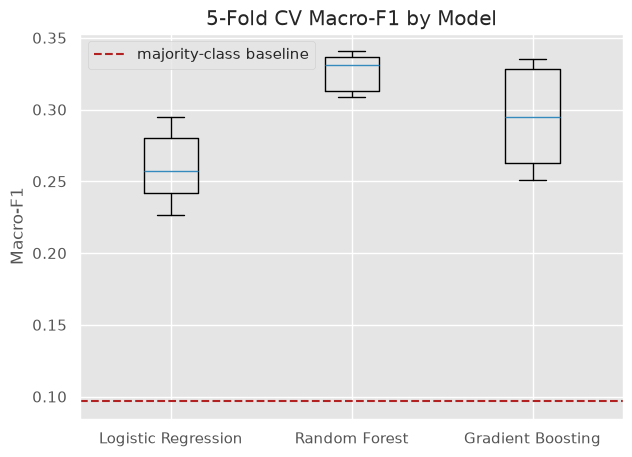

In [7]:
plt.figure(figsize = (7, 5))
plt.boxplot(cv_results.values(), tick_labels = cv_results.keys())
plt.axhline(baseline_f1, color = 'firebrick', linestyle = '--', label = 'majority-class baseline')
plt.title('5-Fold CV Macro-F1 by Model')
plt.ylabel('Macro-F1')
plt.legend()
plt.show()

Random Forest comes out on top and all three comfortably beat the baseline. Going with Random Forest and tuning it a bit further.

## Hyperparameter tuning

Small grid search over the parameters that matter most for a Random Forest - tree count, depth, and leaf size - still scored on macro-F1 with the same 5-fold CV.

In [8]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 3],
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight = 'balanced', random_state = RANDOM_STATE, n_jobs = -1),
    param_grid, scoring = 'f1_macro', cv = cv, n_jobs = -1)

grid_search.fit(X_train, y_train)

print('best params:', grid_search.best_params_)
print(f"best CV macro-F1: {grid_search.best_score_:.3f}")

best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
best CV macro-F1: 0.328


In [9]:
best_model = grid_search.best_estimator_
val_pred = best_model.predict(X_val)
print(f"validation macro-F1: {f1_score(y_val, val_pred, average = 'macro'):.3f}")

validation macro-F1: 0.280


## Final evaluation on the test set

Refitting the tuned model on train + validation together, then scoring once on the test set that hasn't been touched until now.

In [10]:
X_trainval = pd.concat([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

best_model.fit(X_trainval, y_trainval)
test_pred = best_model.predict(X_test)

print(f"test macro-F1: {f1_score(y_test, test_pred, average = 'macro'):.3f}")
print()
print(classification_report(y_test, test_pred, target_names = le_target.classes_))

test macro-F1: 0.314

                             precision    recall  f1-score   support

           ALL OTHER CAUSES       0.36      0.22      0.28        18
                  CORROSION       0.51      0.70      0.59        89
          EXCAVATION DAMAGE       0.29      0.29      0.29        14
        INCORRECT OPERATION       0.16      0.19      0.17        57
MATERIAL/WELD/EQUIP FAILURE       0.66      0.54      0.60       216
       NATURAL FORCE DAMAGE       0.24      0.33      0.28        18
 OTHER OUTSIDE FORCE DAMAGE       0.00      0.00      0.00         8

                   accuracy                           0.49       420
                  macro avg       0.32      0.32      0.31       420
               weighted avg       0.51      0.49      0.49       420



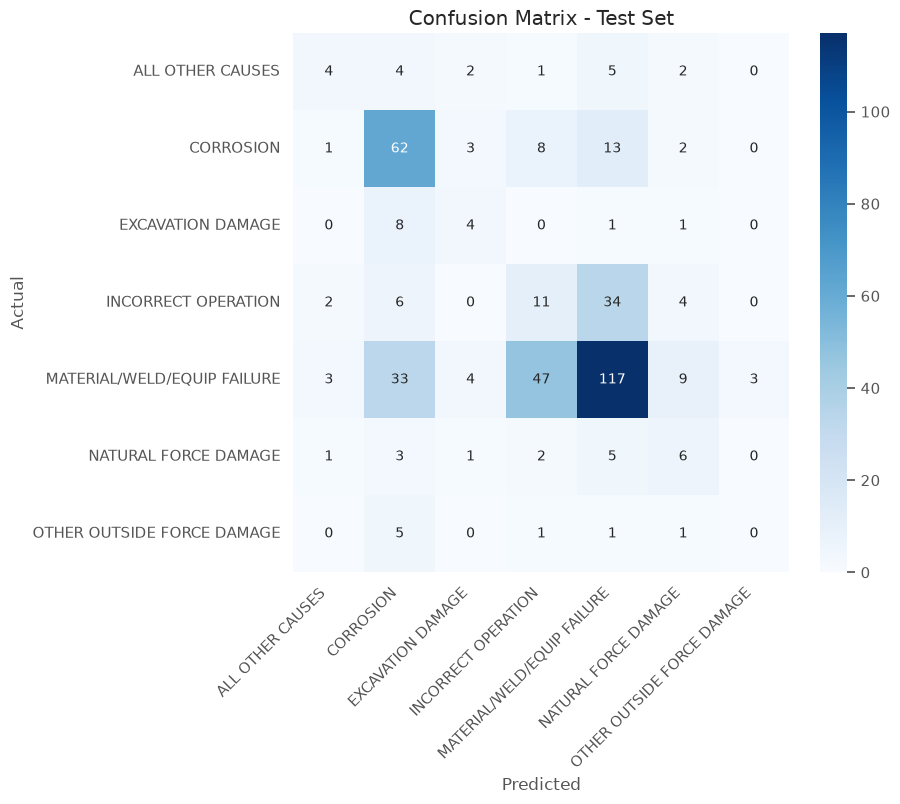

In [11]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize = (8, 7))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = le_target.classes_, yticklabels = le_target.classes_)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation = 45, ha = 'right')
plt.show()

`MATERIAL/WELD/EQUIP FAILURE` and `CORROSION` (the two largest classes) get
picked up reasonably well. The rarer categories - `OTHER OUTSIDE FORCE
DAMAGE` in particular, with only 8 test examples - are where the model
struggles, which is exactly what you'd expect given how little training data
exists for them. `INCORRECT OPERATION` is also getting confused with the
bigger classes fairly often.

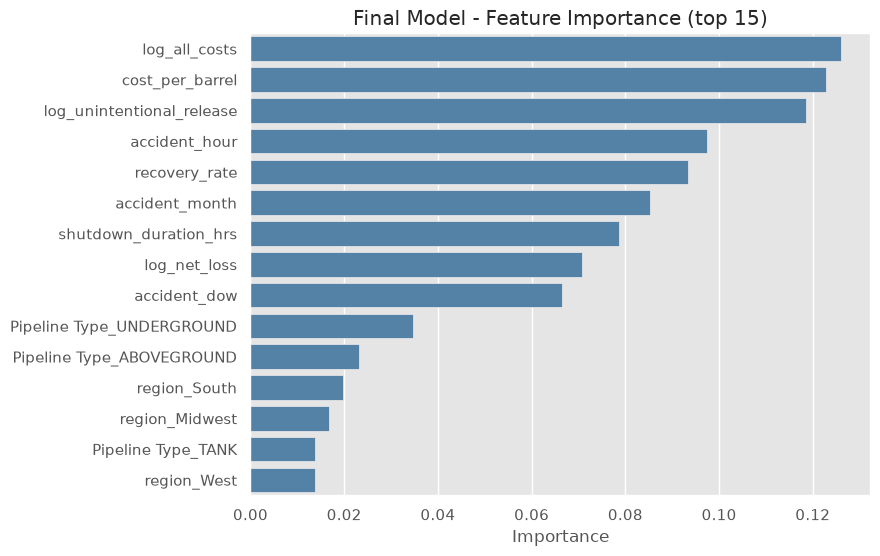

In [12]:
importances = pd.Series(best_model.feature_importances_, index = X.columns).sort_values(ascending = False)

plt.figure(figsize = (8, 6))
top15 = importances.head(15)
sns.barplot(x = top15.values, y = top15.index, color = 'steelblue')
plt.title('Final Model - Feature Importance (top 15)')
plt.xlabel('Importance')
plt.ylabel('')
plt.show()

## Takeaways

- Macro-F1 of ~0.31 on the test set against a ~0.10 majority-class baseline -
  a real improvement, but nowhere near good enough to fully automate cause
  classification. This is a genuinely hard multiclass problem with a lot of
  class imbalance and features that only describe the *consequences* of the
  accident (cost, release volume, location), not root-cause details like
  pipe age or inspection history, which aren't in this dataset.
- Cost, release-volume and recovery-rate features drive most of the model's
  decisions, with `Pipeline Type` adding a meaningful secondary signal -
  consistent with the chi-square result from the statistical testing
  notebook.
- A reasonable next step if this were a real project: get access to
  pipe-level attributes (material, age, inspection history) rather than
  just per-incident consequences, since those are much closer to true causal
  drivers of *why* an accident happened.